In [1]:
#@title EfficientNet-B0 for Facial Expression Recognition

In [2]:
#@title Import Libraries

import os
import copy
import time
import kagglehub
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

In [3]:
#@title Configuration

# Automatically choose GPU if available, else CPU will be choosen
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameter of the configuration
CONFIG = {
    "image_size": 224,	# Resize the input image size to 224 by 224
    "num_classes": 7,	# Label / Class
    "batch_size": 64,	# Process 64 images per weight update (as one batch)
    "epochs": 20,		# Training epochs setting
    "lr": 1e-4,			# Adam's learning rate setting
    "weight_decay": 1e-3,	# L2 regularisation penalty added to the loss
}

# Will be populated automatically from ImageFolder
EXPRESSION_LABELS = []

In [4]:
#@title Data Transforms
from torchvision import transforms

def get_transforms(is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Before grayscale
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

In [5]:
#@title Data Loading

def get_dataloaders():
    print("Fetching dataset via kagglehub (cached if already downloaded)...")

    # Download the dataset from kaggle
    kaggle_path = kagglehub.dataset_download(
        "jonathanoheix/face-expression-recognition-dataset"
    )

    print(f"Dataset path: {kaggle_path}")

    # Resolve nested images/images folder
    base_data_path = os.path.join(kaggle_path, "images", "images")

    # Fallback search if the folder structure changed
    if not os.path.isdir(base_data_path):
        base_data_path = None

        # Walk thru the kagger folder and search for train, validation folder
        for root_dir, dirs, _ in os.walk(kaggle_path):
            if "train" in dirs and "validation" in dirs:
                base_data_path = root_dir
                break

        # Stop the program if the folders cannot be found
        if base_data_path is None:
            raise FileNotFoundError("Could not locate dataset folders.")

    # Build path to train, validation, and test dataset
    train_dir = os.path.join(base_data_path, "train")
    val_dir = os.path.join(base_data_path, "validation")
    test_dir = os.path.join(base_data_path, "test")

    # If the test folder cannot be found, then the validation dataset will be used.
    if not os.path.isdir(test_dir):
        print("No test folder found. Reusing validation as test set.")
        test_dir = val_dir

    # Create PyTorch Datasets
    # 'True' => Indicates augmentation is enabled
    # 'False' => Indicates resize and normalization only
    train_ds = datasets.ImageFolder(train_dir, transform=get_transforms(True))
    val_ds = datasets.ImageFolder(val_dir, transform=get_transforms(False))
    test_ds = datasets.ImageFolder(test_dir, transform=get_transforms(False))

    # Create Training Loader
    train_loader = DataLoader(
        train_ds, # dataset to load
        batch_size=CONFIG["batch_size"], # Number of images per batch
        shuffle=True, # Randomize training data
        num_workers=2, # Uses two background processes to load image faster
        pin_memory=torch.cuda.is_available(), # Enabled when GPU available to speed up data transfer
    )

    # Create Validation Loader
    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False, # No shuffle is needed because order does not affect valuation
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    # Create Test Loader
    test_loader = DataLoader(
        test_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False, # No shuffle is needed because order does not affect valuation
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    # Display size of each dataset and the label
    print(f"Train: {len(train_ds):,}")
    print(f"Validation: {len(val_ds):,}")
    print(f"Test: {len(test_ds):,}")
    print(f"Classes: {train_ds.classes}")

    return train_loader, val_loader, test_loader, train_ds.classes

In [6]:
#@title EfficientNet-B0 Model
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetB0FER(nn.Module):
    def __init__(self, num_classes=7, freeze_backbone=True):
        super().__init__()

        # Load pretrained EfficientNet-B0
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        # Freeze all layers first
        if freeze_backbone:
            for param in backbone.parameters():
                param.requires_grad = False

            # Unfreeze last conv block (features[7:]) — equivalent to layer4 in ResNet
            for param in backbone.features[7:].parameters():
                param.requires_grad = True

        # Replace classifier head
        # EfficientNet-B0 classifier: [Dropout, Linear(1280, 1000)]
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Dropout(0.7),                        # stronger dropout to reduce overfitting
            nn.Linear(in_features, num_classes),
        )

        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

In [7]:
# To count the trainable parameter in the neutral network
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
#@title Training and Evaluation Function

def train_one_epoch(model, loader, criterion, optimizer):
    model.train() # Set the model to training mode

    # Initialize the tracking variables which will accumulates across epochs
    total_loss = 0.0
    correct = 0
    total = 0

    # Loop over mini-batches
    for images, labels in loader:
        images = images.to(DEVICE) # Move tensors to cpu / gpu
        labels = labels.to(DEVICE)

        optimizer.zero_grad() # Initialize gradients

        # Forward Pass
        outputs = model(images) # Compute predictions
        loss = criterion(outputs, labels) # Compute the loss

        # Backpropagation
        loss.backward() # Computes loss gradients
        optimizer.step() # Update the weight / parameter using adjusted gradient

        total_loss += loss.item() * images.size(0) # Count the accumulate loss
        preds = outputs.argmax(dim=1) # Get the prediction
        correct += (preds == labels).sum().item() # Count the correct predictions
        total += labels.size(0) # Count total sample

    return total_loss / total, correct / total


@torch.no_grad() # Disable gradient computation for faster execution and lower memory usage.
def evaluate(model, loader, criterion):
    model.eval() # Switch to evaluation mode

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward Pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Compute the total loss, and accuracy
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [9]:
#@title Epoch Training
def train(model, train_loader, val_loader, epochs):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    patience_counter = 0
    EARLY_STOP_PATIENCE = 3

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion
        )

        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]["lr"]

        if new_lr < prev_lr:
            print(f"  => LR reduced: {prev_lr:.2e} => {new_lr:.2e}")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%"
        )

        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  => New best model saved. Val Acc: {val_acc*100:.2f}%")
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    return history

In [10]:
#@title Display Training/Validation Curve

def plot_training_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"], label="Validation")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross Entropy Loss")
    ax1.legend()
    ax1.grid(True)

    # Accuracy
    ax2.plot([x * 100 for x in history["train_acc"]], label="Train")
    ax2.plot([x * 100 for x in history["val_acc"]], label="Validation")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

In [11]:
#@title Display Sample Prediction Result

@torch.no_grad()
def predict_batch(model, loader, class_names, n=8):
    model.eval()

    images, labels = next(iter(loader))
    images_device = images[:n].to(DEVICE)

    outputs = model(images_device)
    preds = outputs.argmax(dim=1).cpu()

    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    axes = axes.flatten()

    for i in range(n):
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = images[i].cpu().numpy().transpose(1, 2, 0)  # CHW → HWC
        img  = img * std + mean  # denormalization: pixel = normalized * std + mean
        img  = np.clip(img, 0, 1)

        axes[i].imshow(img)  # RGB image

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]

        color = "green" if true_label == pred_label else "red"

        axes[i].set_title(
            f"T: {true_label}\nP: {pred_label}",
            color=color,
            fontsize=8,
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150)
    plt.show()

Device: cuda
Fetching dataset via kagglehub (cached if already downloaded)...
Using Colab cache for faster access to the 'face-expression-recognition-dataset' dataset.
Dataset path: /kaggle/input/face-expression-recognition-dataset
No test folder found. Reusing validation as test set.
Train: 28,821
Validation: 7,066
Test: 7,066
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Class label mapping:
  0: angry
  1: disgust
  2: fear
  3: happy
  4: neutral
  5: sad
  6: surprise

Sample labels:
[3, 5, 1, 4, 4, 0, 3, 3, 4, 0]
['happy', 'sad', 'disgust', 'neutral', 'neutral', 'angry', 'happy', 'happy', 'neutral', 'angry']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 222MB/s]


Model parameters: 1,138,359

-- Training --


Epoch   1/20 | Train Loss: 1.6644, Acc: 34.10% | Val Loss: 1.4696, Acc: 45.34%
  => New best model saved. Val Acc: 45.34%
Epoch   2/20 | Train Loss: 1.4556, Acc: 44.04% | Val Loss: 1.3446, Acc: 49.65%
  => New best model saved. Val Acc: 49.65%
Epoch   3/20 | Train Loss: 1.3688, Acc: 47.56% | Val Loss: 1.2782, Acc: 52.21%
  => New best model saved. Val Acc: 52.21%
Epoch   4/20 | Train Loss: 1.3111, Acc: 50.13% | Val Loss: 1.2169, Acc: 54.44%
  => New best model saved. Val Acc: 54.44%
Epoch   5/20 | Train Loss: 1.2694, Acc: 51.55% | Val Loss: 1.1794, Acc: 55.80%
  => New best model saved. Val Acc: 55.80%
Epoch   6/20 | Train Loss: 1.2379, Acc: 52.73% | Val Loss: 1.1585, Acc: 56.03%
  => New best model saved. Val Acc: 56.03%
Epoch   7/20 | Train Loss: 1.2145, Acc: 54.15% | Val Loss: 1.1400, Acc: 56.92%
  => New best model saved. Val Acc: 56.92%
Epoch   8/20 | Train Loss: 1.1894, Acc: 54.68% | Val Loss: 1.1270, Acc: 57.27%
  => New best model saved. Val Acc: 57.27%
Epoch   9/20 | Train Los

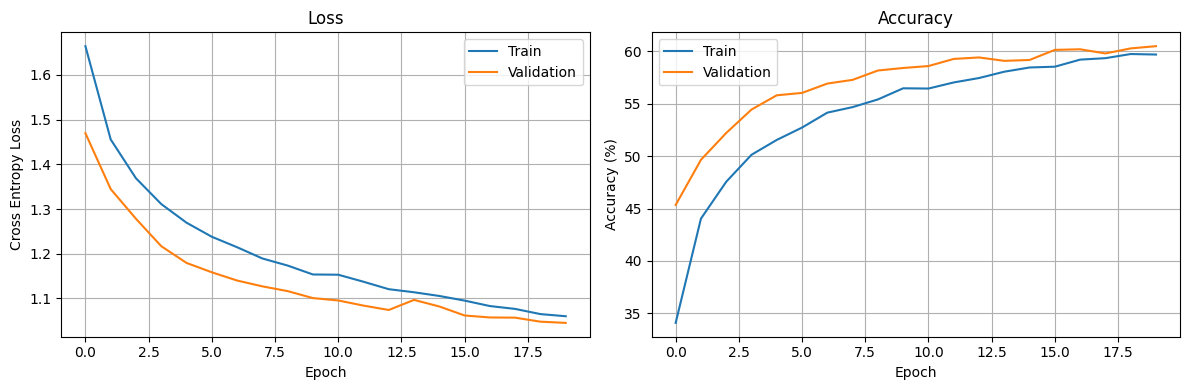

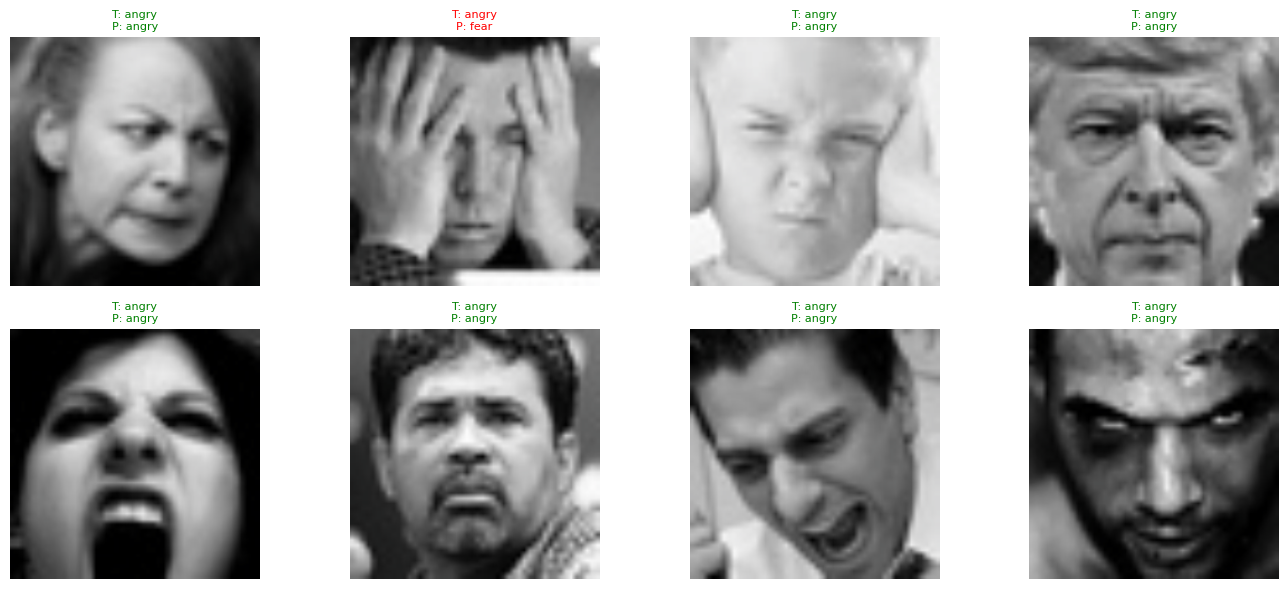

In [12]:
#@title Main Function
def main():
    global EXPRESSION_LABELS

    print(f"Device: {DEVICE}")

    # Load data
    train_loader, val_loader, test_loader, EXPRESSION_LABELS = get_dataloaders()

    print("\nClass label mapping:")
    for idx, name in enumerate(EXPRESSION_LABELS):
        print(f"  {idx}: {name}")

    # Sanity check labels
    images, labels = next(iter(train_loader))
    print("\nSample labels:")
    print(labels[:10].tolist())
    print([EXPRESSION_LABELS[i] for i in labels[:10].tolist()])

    # Model
    model_efficientnet = EfficientNetB0FER(
        num_classes=CONFIG["num_classes"],
        freeze_backbone=True,
    ).to(DEVICE)

    print(f"\nModel parameters: {count_parameters(model_efficientnet):,}")

    # Train
    print("\n-- Training --")
    history = train(
        model_efficientnet,
        train_loader,
        val_loader,
        CONFIG["epochs"],
    )

    # Load best model
    model_efficientnet.load_state_dict(
        torch.load("best_model.pth", map_location=DEVICE)
    )

    # Final evaluation
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate(model_efficientnet, test_loader, criterion)

    print("\n-- Test Results --")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")

    # Plot curves
    plot_training_curves(history)

    # Show predictions
    predict_batch(model_efficientnet, test_loader, EXPRESSION_LABELS)


if __name__ == "__main__":
    main()